In [ ]:
import tensorflow as tf
from tensorflow. keras import models, layers
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(dataset_train_original, dataset_validate_original, dataset_test_original), info = tfds.load(
    "cats_vs_dogs" ,
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    with_info=True,
    as_supervised=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/23262 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.0U0Z40_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
# info

In [ ]:
# image size 72,72 trains fast, but still needs to be big enough
# 1024, 768: now
# 3000x4000 holyday pics

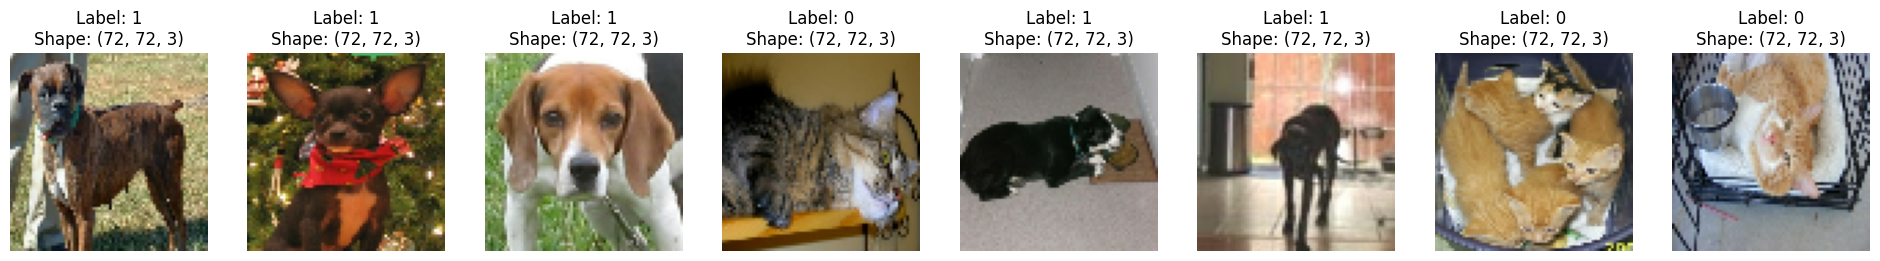

In [ ]:
def encode(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    image = tf.image.resize(image, (72, 72))
    return image, label

dataset = dataset_train_original.map(encode)

index = 1
num_samples = 8
plt.figure(figsize=(24, 4))
for image, label in dataset.take(num_samples):
    plt.subplot(1, num_samples, index)
    plt.imshow(image)
    plt.title(f"Label: {label}\nShape: {image.shape}")
    plt.axis("off")
    index += 1

In [ ]:
batch_size = 128
dataset_train = dataset_train_original.map(lambda image, label: encode(image, label)).cache().shuffle(16_284).batch(batch_size)
dataset_validate = dataset_validate_original.map(lambda image, label: encode(image, label)).cache().batch(batch_size)
dataset_test = dataset_test_original.map(lambda image, label: encode(image, label)).cache().batch(batch_size)

In [ ]:
# shuffle buffer size: should be roundabout the size of the dataset
# 23000 is dataset size
# 16284*0.75

In [ ]:
history_list = {}
epochs = 50

def render_history(history):
    plt.plot(history["loss"], label="loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Our losses")
    plt.show()
    plt.close()

    plt.plot(history["accuracy"], label="accuracy")
    plt.plot(history["val_accuracy"], label="val_accuracy")
    plt.legend()
    plt.title("Our accuracies")
    plt.show()
    plt.close()


def compare_histories():
    for training_name, history in history_list.items():
        plt.plot(history["val_accuracy"], label=training_name)
    plt.legend()
    plt.title("Comparison of val_accuracy")
    plt.show()
    plt.close()

In [ ]:
image_size=72

In [ ]:
model = models. Sequential()
model.add(layers.Input(shape=(image_size, image_size, 3)))
for i in range(2):
    model.add(layers.Conv2D(32, 3, activation="relu"))
    model.add(layers.MaxPooling2D(2))
model.add(layers.Flatten())
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 70, 70, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 35, 35, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 33, 33, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │           8,193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,337 (71.63 KB)

 Trainable params: 18,337 (71.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model.compile(optimizer="adam", loss="binary_crossentropy", metrics= ["accuracy"])
# history = model.fit(
#     dataset_train,
#     epochs=10,
#     validation_data=dataset_validate
# )

# history_list["cnn"] = history.history
# render_history(history.history)
# compare_histories()

# render_history(history.history)

In [ ]:
# now we have baseline
# 99% should be possible

# Vision Transformer

In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

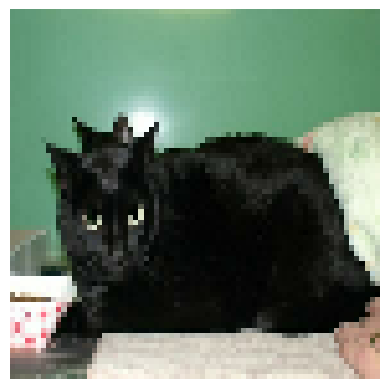

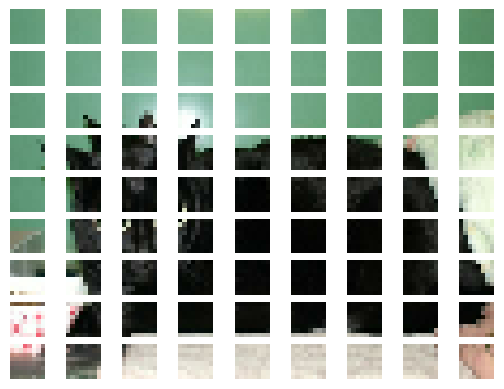

In [ ]:
patch_size = 8 # make sure everything is divisible

dataset = dataset_train_original.map(lambda image, label: encode(image, label)).shuffle(100).batch(1)
patches_layer = Patches(patch_size=patch_size)

for image_batch, _ in dataset.take(1):

    # Render original image.
    plt.imshow(image_batch[0])
    plt.axis("off")
    plt.show()

    # Render patches.
    patches = patches_layer(image_batch)
    n = int(np.sqrt(patches.shape[1]))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = tf.reshape(patch, (patch_size, patch_size, 3))
        plt.imshow(patch_img.numpy())
        plt.axis("off")

In [ ]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
        # layers.Dense and layers.Embedding is randomly initialized

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

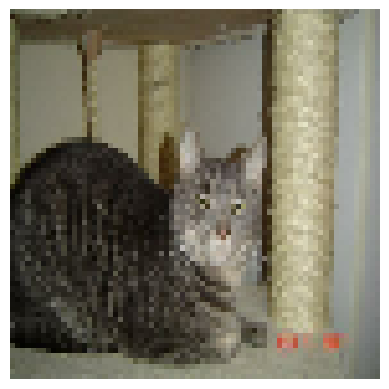

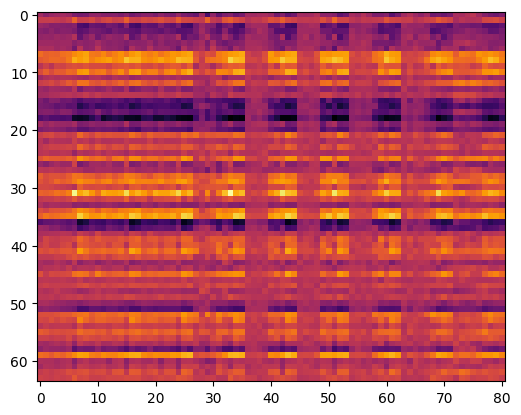

In [ ]:
patch_size = 8
num_patches = (image_size // patch_size) ** 2
embed_dim = 64 # Consider going down.

dataset = dataset_train_original.map(lambda image, label: encode(image, label)).shuffle(100).batch(1)
patches_layer = Patches(patch_size=patch_size)
patch_encoder_layer = PatchEncoder(num_patches=num_patches, projection_dim=embed_dim)

for image_batch, _ in dataset.take(1):

    # Render original image.
    plt.imshow(image_batch[0])
    plt.axis("off")
    plt.show()

    # Render encoded patches.
    patches = patches_layer(image_batch)
    patch_encoding = patch_encoder_layer(patches)
    plt.imshow(patch_encoding[0].numpy().transpose(), cmap="inferno")

In [ ]:
# 81=9*9 patches
# 64=embed_dim
# this 81x64 is what transformers work with all the time

In [ ]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = tf.keras.Sequential(
            [
             layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),
             ]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs):
        normalized_inputs = self.layernorm_1(inputs)
        attention_outputs = self.attention(normalized_inputs, normalized_inputs, normalized_inputs)
        sum = inputs + attention_outputs
        normalized_sum = self.layernorm_2(sum)
        projection_output = self.dense_proj(normalized_sum)
        result = sum + projection_output # BUG FIX!
        return result

In [ ]:
patch_size = 8
num_patches = 81
num_heads = 4
num_encoders = 2
embed_dim = 16

model = models.Sequential()
model.add(layers.Input(shape=(72,72,3)))
model.add(Patches(patch_size=patch_size))
model.add(PatchEncoder(num_patches=num_patches, projection_dim=embed_dim))
for _ in range(num_encoders):
    model.add(TransformerEncoder(embed_dim=embed_dim, dense_dim=embed_dim*2, num_heads=num_heads))
model.add(layers.GlobalAvgPool1D())  # 81 things get averaged
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ patches_3 (Patches)                  │ (None, None, 192)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ patch_encoder_2 (PatchEncoder)       │ (None, 81, 16)              │           4,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_2                │ (None, 81, 16)              │           5,440 │
│ (TransformerEncoder)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_3                │ (None, 81, 16)              │           5,440 │
│ (TransformerEncoder)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 16)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,281 (59.69 KB)

 Trainable params: 15,281 (59.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
pred = model.predict(image.numpy().reshape(1, 72, 72, 3))
pred.shape
# (1, 81, 192)
# 9x9
# 64*3

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 1)

In [ ]:
image.shape

TensorShape([72, 72, 3])

In [ ]:
# 8x8

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics= ["accuracy"])
history = model.fit(
    dataset_train,
    epochs=10,
    validation_data=dataset_validate
)

history_list["vit"] = history.history

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.5379 - loss: 0.7084 - val_accuracy: 0.5702 - val_loss: 0.6714
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5786 - loss: 0.6746 - val_accuracy: 0.5951 - val_loss: 0.6612
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6181 - loss: 0.6497 - val_accuracy: 0.6384 - val_loss: 0.6315
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6440 - loss: 0.6240 - val_accuracy: 0.6616 - val_loss: 0.6074
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6731 - loss: 0.5984 - val_accuracy: 0.6315 - val_loss: 0.6333
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6751 - loss: 0.5917 - val_accuracy: 0.6762 - val_loss: 0.5900
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6992 - loss: 0.5664 - val_accuracy: 0.6625 - val_loss: 0.6120
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7078 - loss: 0.5623 - val_ac

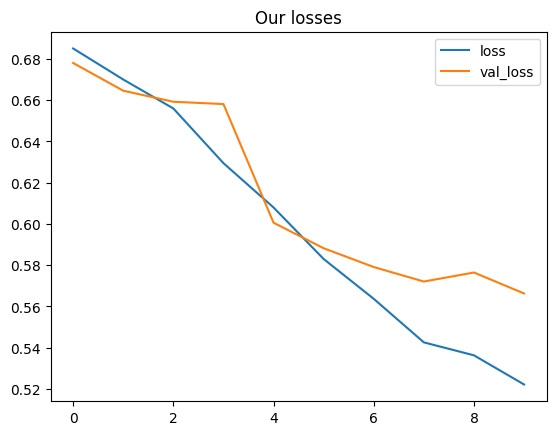

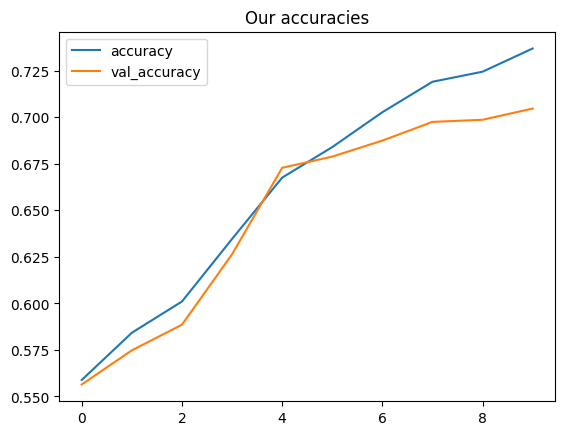

In [ ]:
render_history(history.history)
# compare_histories()